# Delhi Weather Forecasting

This notebook forecasts Delhi's daily mean temperature 14 days ahead from four years of daily weather observations, and checks whether a trained model actually beats the simplest possible forecast: tomorrow will look like today.

It began as a university assignment on applied AI for business. A naive baseline and a validation split are added here so the model's performance means something, and a second model tests whether extra weather variables (humidity, wind, pressure) actually help. See the README for the full writeup.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import RMSprop
from tensorflow.random import set_seed

np.random.seed(311)
set_seed(311)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
PALETTE = ["#2E5A87", "#5B9BD5", "#9DC3E6", "#C0392B"]

N_STEPS = 50
HORIZON = 14
FEATURES = ["meantemp", "humidity", "wind_speed", "meanpressure"]

## 1. Loading and exploring the data

The date column arrives as day/month/year text, so it needs an explicit parse rather than pandas' default guess.

In [2]:
df = pd.read_csv("data/delhi_weather.csv")
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.set_index("Date").sort_index()
print(f"{len(df)} days, {df.isnull().sum().sum()} missing values, {df.index.min().date()} to {df.index.max().date()}")
df.head()

1575 days, 0 missing values, 2013-01-01 to 2017-04-24


,meantemp,humidity,wind_speed,meanpressure
Date,,,,
2013-01-01,10.000000,84.500000,0.000000,10.156667
2013-01-02,7.400000,92.000000,2.980000,10.178000
2013-01-03,7.166667,87.000000,4.633333,10.186667
2013-01-04,8.666667,71.333333,1.233333,10.171667
2013-01-05,6.000000,86.833333,3.700000,10.165000


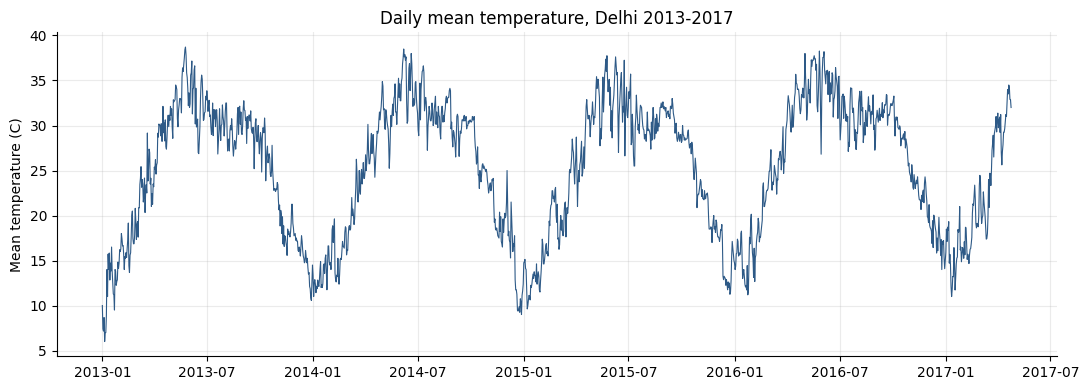

In [3]:
plt.figure(figsize=(11, 4))
plt.plot(df.index, df["meantemp"], color=PALETTE[0], linewidth=0.8)
plt.title("Daily mean temperature, Delhi 2013-2017")
plt.ylabel("Mean temperature (C)")
plt.tight_layout()
plt.show()

/var/folders/t7/x8x9z7zn2m14gph81bqs937c0000gn/T/ipykernel_65246/1197238128.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_by_year = df["meantemp"].resample("M").mean()


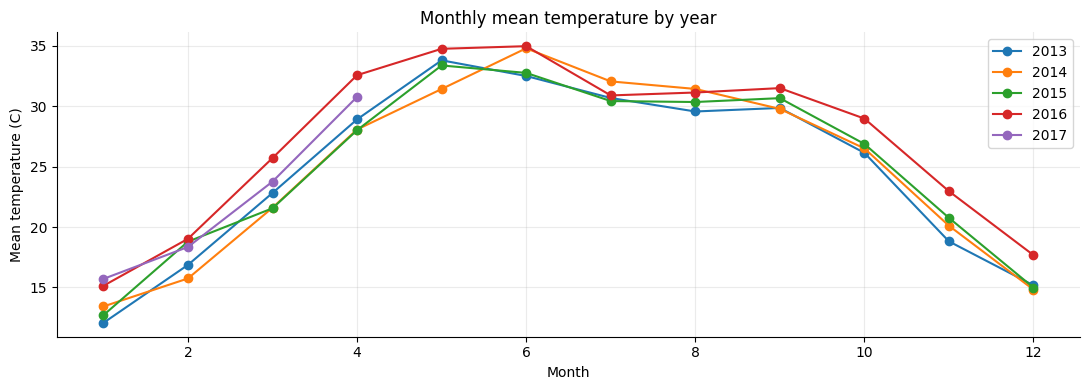

In [4]:
monthly_by_year = df["meantemp"].resample("M").mean()
plt.figure(figsize=(11, 4))
for year in [2013, 2014, 2015, 2016, 2017]:
    yearly = monthly_by_year[monthly_by_year.index.year == year]
    if len(yearly):
        plt.plot(yearly.index.month, yearly.values, marker="o", label=str(year))
plt.xlabel("Month")
plt.ylabel("Mean temperature (C)")
plt.title("Monthly mean temperature by year")
plt.legend()
plt.tight_layout()
plt.show()

2016 runs at or above the other years for most of the calendar, matching what the original assignment noticed. 2017's line stops in April, since the data for that year is incomplete, so its lower yearly average reflects a partial year of cooler months rather than a genuinely milder year.

## 2. Train and test split

Same split as the original: 2013 to 2016 for training, 2017 held out for testing. This respects the time order of the data, which matters for forecasting: shuffling would let the model see the future while training.

In [5]:
train_df = df.loc["2013":"2016"]
test_df = df.loc["2017":]
print(f"Train: {len(train_df)} days, Test: {len(test_df)} days")


def make_sequences(values, n_steps, horizon):
    X, y = [], []
    for i in range(len(values) - n_steps - horizon + 1):
        X.append(values[i:i + n_steps])
        y.append(values[i + n_steps:i + n_steps + horizon, 0])
    return np.array(X), np.array(y)


def evaluate(y_true, y_pred, label):
    mae_per_day = [mean_absolute_error(y_true[:, i], y_pred[:, i]) for i in range(HORIZON)]
    print(f"{label}: average MAE across horizon = {np.mean(mae_per_day):.3f}")
    return mae_per_day

Train: 1461 days, Test: 114 days


## 3. Naive baseline

Before trusting any model, it needs something to beat. The simplest reasonable forecast: whatever the temperature is today, assume it stays there for the next 14 days.

In [6]:
train_temp = train_df["meantemp"].values.reshape(-1, 1)
test_temp = test_df["meantemp"].values.reshape(-1, 1)

X_test_raw, y_test_raw = make_sequences(test_temp, N_STEPS, HORIZON)
naive_pred = np.repeat(X_test_raw[:, -1, :], HORIZON, axis=1)
naive_mae = evaluate(y_test_raw, naive_pred, "Naive baseline")

Naive baseline: average MAE across horizon = 3.188


## 4. Univariate LSTM

A single LSTM layer trained on 50 days of past temperature to predict the next 14, matching the original assignment's approach. A validation split and early stopping are added so training doesn't run a fixed 100 epochs regardless of whether the model is still improving.

In [7]:
sc_uni = MinMaxScaler(feature_range=(0, 1))
train_scaled_uni = sc_uni.fit_transform(train_temp)
test_scaled_uni = sc_uni.transform(test_temp)

X_train_uni, y_train_uni = make_sequences(train_scaled_uni, N_STEPS, HORIZON)
X_test_uni, y_test_uni = make_sequences(test_scaled_uni, N_STEPS, HORIZON)

lstm_uni = Sequential([
    LSTM(units=100, activation="tanh", input_shape=(N_STEPS, 1)),
    Dense(units=HORIZON),
])
lstm_uni.compile(optimizer=RMSprop(), loss="mse")
history_uni = lstm_uni.fit(
    X_train_uni, y_train_uni,
    validation_split=0.1,
    epochs=100, batch_size=32, verbose=0,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
)
print(f"Stopped after {len(history_uni.history['loss'])} epochs")

pred_scaled_uni = lstm_uni.predict(X_test_uni, verbose=0)
pred_uni = sc_uni.inverse_transform(pred_scaled_uni)
y_test_uni_inv = sc_uni.inverse_transform(y_test_uni)
uni_mae = evaluate(y_test_uni_inv, pred_uni, "LSTM (temperature only)")

/Users/ahmet/Workings/analytics-portfolio/projects/delhi-weather-forecasting/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Stopped after 34 epochs
LSTM (temperature only): average MAE across horizon = 2.871


## 5. Multivariate LSTM

Same architecture, but each timestep also carries humidity, wind speed, and pressure, to test whether giving the model more to work with actually helps.

In [8]:
sc_multi = MinMaxScaler(feature_range=(0, 1))
train_scaled_multi = sc_multi.fit_transform(train_df[FEATURES].values)
test_scaled_multi = sc_multi.transform(test_df[FEATURES].values)


def make_sequences_multi(values, n_steps, horizon, target_col=0):
    X, y = [], []
    for i in range(len(values) - n_steps - horizon + 1):
        X.append(values[i:i + n_steps])
        y.append(values[i + n_steps:i + n_steps + horizon, target_col])
    return np.array(X), np.array(y)


X_train_multi, y_train_multi = make_sequences_multi(train_scaled_multi, N_STEPS, HORIZON)
X_test_multi, y_test_multi = make_sequences_multi(test_scaled_multi, N_STEPS, HORIZON)

lstm_multi = Sequential([
    LSTM(units=100, activation="tanh", input_shape=(N_STEPS, len(FEATURES))),
    Dense(units=HORIZON),
])
lstm_multi.compile(optimizer=RMSprop(), loss="mse")
history_multi = lstm_multi.fit(
    X_train_multi, y_train_multi,
    validation_split=0.1,
    epochs=100, batch_size=32, verbose=0,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
)
print(f"Stopped after {len(history_multi.history['loss'])} epochs")

pred_scaled_multi = lstm_multi.predict(X_test_multi, verbose=0)
pad_pred = np.zeros((pred_scaled_multi.shape[0], HORIZON, len(FEATURES)))
pad_true = np.zeros((y_test_multi.shape[0], HORIZON, len(FEATURES)))
for h in range(HORIZON):
    pad_pred[:, h, 0] = pred_scaled_multi[:, h]
    pad_true[:, h, 0] = y_test_multi[:, h]
pred_multi = np.stack([sc_multi.inverse_transform(pad_pred[:, h, :])[:, 0] for h in range(HORIZON)], axis=1)
y_test_multi_inv = np.stack([sc_multi.inverse_transform(pad_true[:, h, :])[:, 0] for h in range(HORIZON)], axis=1)
multi_mae = evaluate(y_test_multi_inv, pred_multi, "LSTM (+ weather features)")

/Users/ahmet/Workings/analytics-portfolio/projects/delhi-weather-forecasting/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Stopped after 42 epochs
LSTM (+ weather features): average MAE across horizon = 2.899


## 6. Comparing the three approaches

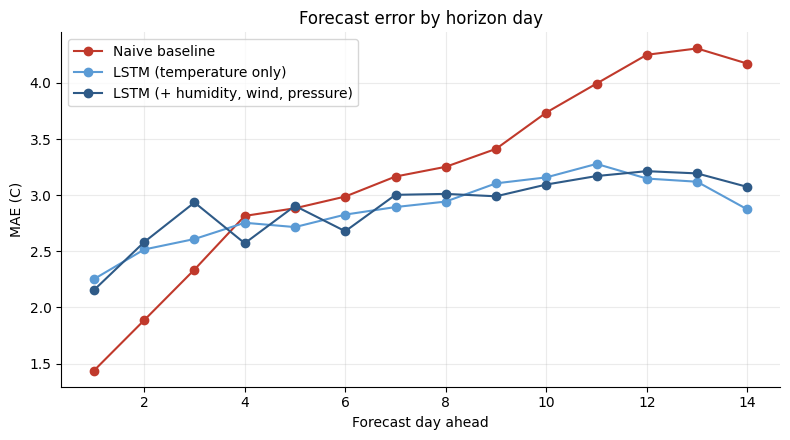

In [9]:
days = np.arange(1, HORIZON + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(days, naive_mae, marker="o", label="Naive baseline", color=PALETTE[3])
plt.plot(days, uni_mae, marker="o", label="LSTM (temperature only)", color=PALETTE[1])
plt.plot(days, multi_mae, marker="o", label="LSTM (+ humidity, wind, pressure)", color=PALETTE[0])
plt.xlabel("Forecast day ahead")
plt.ylabel("MAE (C)")
plt.title("Forecast error by horizon day")
plt.legend()
plt.tight_layout()
plt.show()

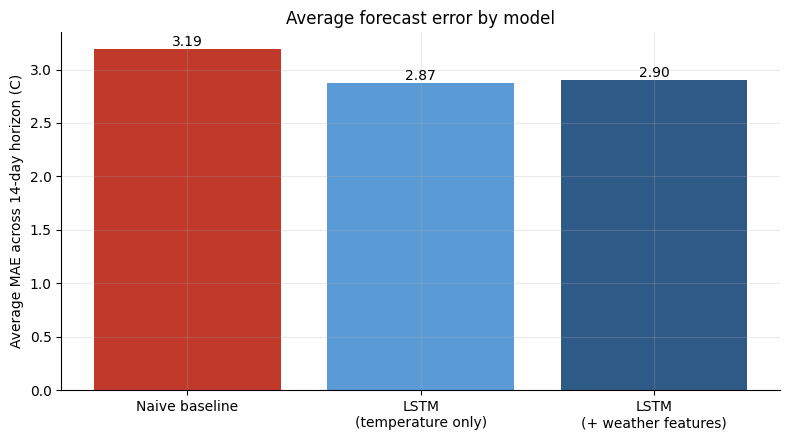

In [10]:
labels = ["Naive baseline", "LSTM\n(temperature only)", "LSTM\n(+ weather features)"]
avgs = [np.mean(naive_mae), np.mean(uni_mae), np.mean(multi_mae)]
plt.figure(figsize=(8, 4.5))
plt.bar(labels, avgs, color=[PALETTE[3], PALETTE[1], PALETTE[0]])
for i, v in enumerate(avgs):
    plt.text(i, v + 0.03, f"{v:.2f}", ha="center")
plt.ylabel("Average MAE across 14-day horizon (C)")
plt.title("Average forecast error by model")
plt.tight_layout()
plt.show()

Both LSTM models clearly beat the naive baseline, but the multivariate model does not improve on the univariate one, it lands slightly behind it. Daily mean temperature is highly autocorrelated on its own, so most of what a short term forecast needs is already in the recent trend; the extra variables mostly add noise and dimensionality that a single 100 unit LSTM, trained on only four years of data, doesn't have enough signal to exploit. That is a genuine negative result, not a modeling mistake, and it says something useful: collecting more weather inputs isn't automatically worth the effort on data and a model this size.

## 7. What a forecast actually looks like

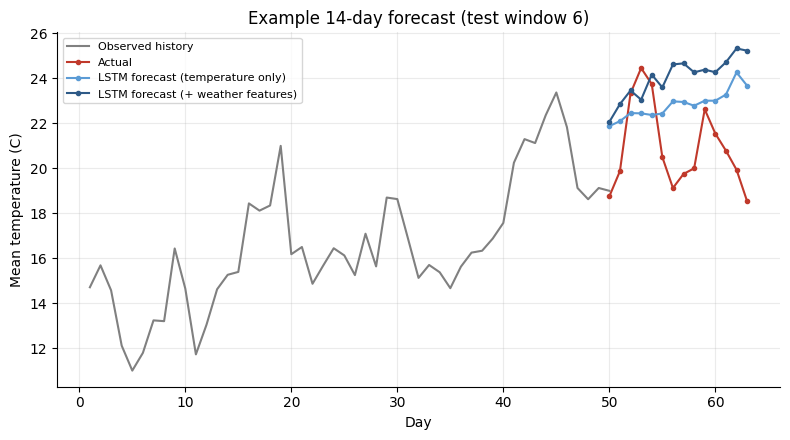

In [11]:
sample_index = 6
history_x = np.arange(1, N_STEPS + 1)
future_x = np.arange(N_STEPS, N_STEPS + HORIZON)

plt.figure(figsize=(8, 4.5))
plt.plot(history_x, sc_uni.inverse_transform(X_test_uni[sample_index]), label="Observed history", color="gray")
plt.plot(future_x, y_test_uni_inv[sample_index], label="Actual", color=PALETTE[3], marker="o", markersize=3)
plt.plot(future_x, pred_uni[sample_index], label="LSTM forecast (temperature only)", color=PALETTE[1], marker="o", markersize=3)
plt.plot(future_x, pred_multi[sample_index], label="LSTM forecast (+ weather features)", color=PALETTE[0], marker="o", markersize=3)
plt.title(f"Example 14-day forecast (test window {sample_index})")
plt.ylabel("Mean temperature (C)")
plt.xlabel("Day")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

Both models track the general trend reasonably well but smooth over the sharper day to day swings the actual temperature takes within the window. That's a fair characterization of what these models are good for: directional and medium term guidance, not exact daily figures two weeks out.

See the [README](README.md) for the full writeup with figures and a discussion of what changed from the original coursework version.